# Declaration of Originality

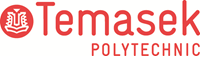

**TEMASEK POLYTECHNIC**
<br>**SCHOOL OF INFORMATICS & IT**
<br>**DIPLOMA IN INFORMATION TECHNOLOGY**
<br>**MACHINE LEARNING FOR DEVELOPERS (CAI2C08)**
<br>**AY2025/2026 OCTOBER SEMESTER**

**PROJECT PROGRAM CODES**
* Student Name (Matric Number)  : Joshua (2400591J)
* Tutorial Group                :  TC03
* Tutor						    :  Ruchir Srivastava
* Submission Date               : 11/2/2026


**Declaration of Originality**
* I am the originator of this work and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Business Understanding
Goal: to predict fitness class of different people

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
df = pd.read_csv("bodyPerformance.csv")



## 2.2 Summary Statistics

In [3]:
# Preview first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

# Check data types
print("\nData types of each column:")
print(df.dtypes)

# Dataset shape
print(f"\nDataset shape: {df.shape}")

First 5 rows of the dataset:
    age gender  height_cm  weight_kg  body fat_%  diastolic  systolic  \
0  27.0      M      172.3      75.24        21.3       80.0     130.0   
1  25.0      M      165.0      55.80        15.7       77.0     126.0   
2  31.0      M      179.6      78.00        20.1       92.0     152.0   
3  32.0      M      174.5      71.10        18.4       76.0     147.0   
4  28.0      M      173.8      67.70        17.1       70.0     127.0   

   gripForce  sit and bend forward_cm  sit-ups counts  broad jump_cm class  
0       54.9                     18.4            60.0          217.0     C  
1       36.4                     16.3            53.0          229.0     A  
2       44.8                     12.0            49.0          181.0     C  
3       41.4                     15.2            53.0          219.0     B  
4       43.5                     27.1            45.0          217.0     B  

Data types of each column:
age                        float64
gender 

In [4]:
# Check for missing values
print("\nMissing data per column:")
print(df.isnull().sum())

# Percentage of missing data per column
missing_percent = df.isnull().mean() * 100
print("\nPercentage of missing data per column:")
print(missing_percent)


Missing data per column:
age                        0
gender                     0
height_cm                  0
weight_kg                  0
body fat_%                 0
diastolic                  0
systolic                   0
gripForce                  0
sit and bend forward_cm    0
sit-ups counts             0
broad jump_cm              0
class                      0
dtype: int64

Percentage of missing data per column:
age                        0.0
gender                     0.0
height_cm                  0.0
weight_kg                  0.0
body fat_%                 0.0
diastolic                  0.0
systolic                   0.0
gripForce                  0.0
sit and bend forward_cm    0.0
sit-ups counts             0.0
broad jump_cm              0.0
class                      0.0
dtype: float64


In [5]:
# Describe numerical features
print("\nSummary statistics for numerical columns:")
print(df.describe())

# Describe categorical columns
print("\nSummary statistics for categorical columns:")
print(df.describe(include=['object']))



Summary statistics for numerical columns:
                age     height_cm     weight_kg    body fat_%     diastolic  \
count  13393.000000  13393.000000  13393.000000  13393.000000  13393.000000   
mean      36.775106    168.559807     67.447316     23.240165     78.796842   
std       13.625639      8.426583     11.949666      7.256844     10.742033   
min       21.000000    125.000000     26.300000      3.000000      0.000000   
25%       25.000000    162.400000     58.200000     18.000000     71.000000   
50%       32.000000    169.200000     67.400000     22.800000     79.000000   
75%       48.000000    174.800000     75.300000     28.000000     86.000000   
max       64.000000    193.800000    138.100000     78.400000    156.200000   

           systolic     gripForce  sit and bend forward_cm  sit-ups counts  \
count  13393.000000  13393.000000             13393.000000    13393.000000   
mean     130.234817     36.963877                15.209268       39.771224   
std       1

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

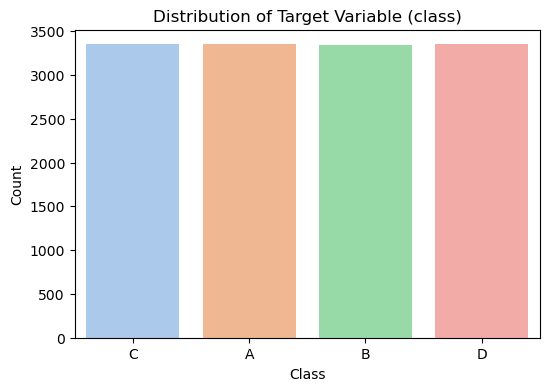

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='class', palette='pastel')
plt.title('Distribution of Target Variable (class)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Justification:
# Helps understand class balance
# If highly imbalanced, might need techniques like stratified sampling or oversampling


### 2.3.1.2 Understanding distribution of features

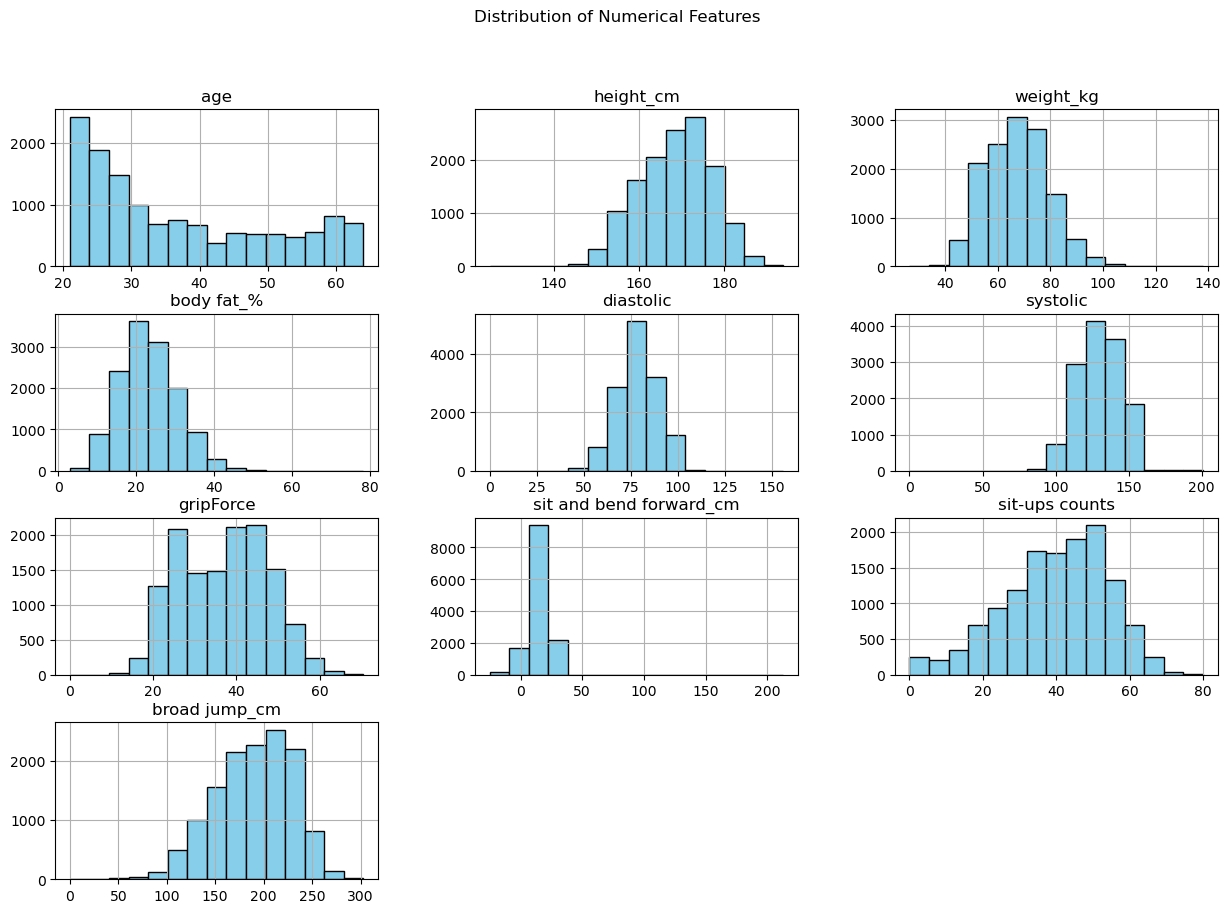

In [10]:
# Histogram for all numeric features
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

df[numeric_cols].hist(bins=15, figsize=(15,10), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Numerical Features')
plt.show()

# Justification:
# Shows the distribution (normal, skewed, etc.) of each numeric feature
# Helps in feature scaling decisions and detecting outliers


### 2.3.2 Understanding relationship between variables

ValueError: num must be an integer with 1 <= num <= 9, not 10

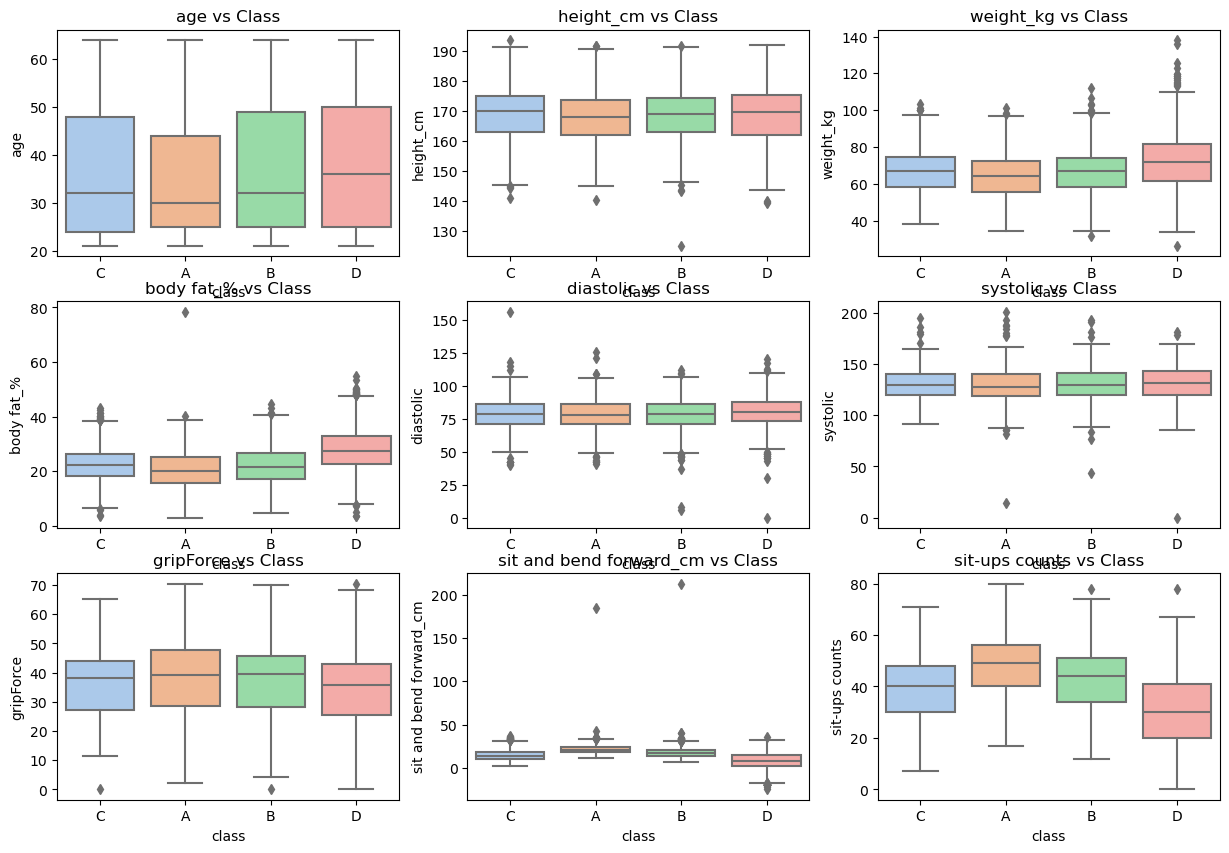

In [11]:
# Boxplots to see how numeric features vary by class
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols):
    if col != 'class':
        plt.subplot(3, 3, i+1)
        sns.boxplot(x='class', y=col, data=df, palette='pastel')
        plt.title(f'{col} vs Class')
plt.tight_layout()
plt.show()

# Justification:
# Boxplots help visualize how features differ across target classes
# Can reveal which features may be more predictive


# 3. Data Preparation

## 3.1 Data Cleaning

In [12]:
df = df.rename(columns={"body fat_%": "body_fat_pct"})
df = df.dropna()

# 3. Feature selection

features = [
    "age",
    "gender",
    "height_cm",
    "weight_kg",
    "body_fat_pct",
    "diastolic",
    "systolic",
    "gripForce"
]

X = df[features]
y = df["class"]

# Encode gender
X = pd.get_dummies(X, columns=["gender"], drop_first=True)

## 3.2 Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 4. Modelling

### 4.2 Train Model

In [14]:
model = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial"
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=2000, multi_class='multinomial')

# 5. Model Evaluation

In [15]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.4423292273236282
              precision    recall  f1-score   support

           A       0.47      0.64      0.54       670
           B       0.33      0.20      0.25       669
           C       0.36      0.30      0.33       670
           D       0.53      0.63      0.58       670

    accuracy                           0.44      2679
   macro avg       0.42      0.44      0.42      2679
weighted avg       0.42      0.44      0.42      2679



In [ ]:
## New data

## Predict


## Iterative model development


In [ ]:
## Further feature engineering / feature selection